In [1]:
!wget https://raw.githubusercontent.com/himanshu4gya/cloud_data/refs/heads/main/obs_dates_str.txt

--2026-06-29 16:34:33--  https://raw.githubusercontent.com/himanshu4gya/cloud_data/refs/heads/main/obs_dates_str.txt
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1005 [text/plain]
Saving to: ‘obs_dates_str.txt’

obs_dates_str.txt   100%[===================>]    1005  --.-KB/s    in 0s      

2026-06-29 16:34:33 (75.2 MB/s) - ‘obs_dates_str.txt’ saved [1005/1005]



In [2]:
!pip install xarray netCDF4

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 43.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 44.6 MB/s eta 0:00:00


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from datetime import datetime
import datetime
import scipy.optimize as curve_fit
import xarray as xr
import os

In [5]:
from google.colab import files
uploaded = files.upload()

Saving ag26.nc to ag26.nc
Saving ag23-24.nc to ag23-24.nc
Saving ag22&25.nc to ag22&25.nc
Saving ag20-21.nc to ag20-21.nc
Saving ag18-19.nc to ag18-19.nc
Saving ag16_17.nc to ag16_17.nc
Saving ag14-15.nc to ag14-15.nc


In [6]:
df2 = pd.read_csv('/content/obs_dates_str.txt')


df2['date'] = pd.to_datetime(df2['Dates'], format='%Y%m%d')

In [7]:
df2

,Dates,date
0,20231202,2023-12-02
1,20230514,2023-05-14
2,20231215,2023-12-15
3,20231107,2023-11-07
4,20240105,2024-01-05
...,...,...
106,20231123,2023-11-23
107,20240119,2024-01-19
108,20240520,2024-05-20
109,20231120,2023-11-20


In [8]:
import xarray as xr
import pandas as pd

# Open files
ds14_15 = xr.open_dataset("ag14-15.nc")
ds16_17 = xr.open_dataset("ag16_17.nc")
ds18_19 = xr.open_dataset("ag18-19.nc")
ds20_21 = xr.open_dataset("ag20-21.nc")
ds22_25 = xr.open_dataset("ag22&25.nc")
ds23_24 = xr.open_dataset("ag23-24.nc")
ds26 = xr.open_dataset("ag26.nc")

# Convert each NetCDF file to DataFrame
df14_15 = ds14_15.to_dataframe().reset_index()
df16_17 = ds16_17.to_dataframe().reset_index()
df18_19 = ds18_19.to_dataframe().reset_index()
df20_21 = ds20_21.to_dataframe().reset_index()
df22_25 = ds22_25.to_dataframe().reset_index()
df23_24 = ds23_24.to_dataframe().reset_index()
df26 = ds26.to_dataframe().reset_index()

# Check the data
print(df14_15.head())
print(df16_17.head())
print(df18_19.head())
print(df20_21.head())
print(df22_25.head())
print(df23_24.head())
print(df26.head())

           valid_time  latitude  longitude       tcc  number expver
0 2014-01-01 00:00:00     32.25      76.25  0.830170       0   0001
1 2014-01-01 00:00:00     32.25      76.50  0.600922       0   0001
2 2014-01-01 00:00:00     32.00      76.25  0.996338       0   0001
3 2014-01-01 00:00:00     32.00      76.50  0.886719       0   0001
4 2014-01-01 01:00:00     32.25      76.25  0.860413       0   0001
           valid_time  latitude  longitude       tcc  number expver
0 2016-01-01 00:00:00     32.25      76.25  0.972565       0   0001
1 2016-01-01 00:00:00     32.25      76.50  0.972565       0   0001
2 2016-01-01 00:00:00     32.00      76.25  0.980591       0   0001
3 2016-01-01 00:00:00     32.00      76.50  0.970001       0   0001
4 2016-01-01 01:00:00     32.25      76.25  0.989746       0   0001
           valid_time  latitude  longitude       tcc  number expver
0 2018-01-01 00:00:00     32.25      76.25  0.221466       0   0001
1 2018-01-01 00:00:00     32.25      76.50  0.36

In [9]:
#######################################
########################################
##########################################3
#INTERPOLATED VALUES
#SITE OBSERVATORY
##############################################
###################################################

In [10]:
import xarray as xr
import pandas as pd

# --------------------------------------------------
# Observatory coordinates
# --------------------------------------------------
LAT = 32.1725
LON = 76.4269

# --------------------------------------------------
# NetCDF files
# --------------------------------------------------
files = [
    "ag14-15.nc",
    "ag16_17.nc",
    "ag18-19.nc",
    "ag20-21.nc",
    "ag22&25.nc",
    "ag23-24.nc",
    "ag26.nc"
]

# --------------------------------------------------
# Empty list to store DataFrames
# --------------------------------------------------
all_data = []

# --------------------------------------------------
# Loop through all files
# --------------------------------------------------
for file in files:

    print(f"Processing {file}")

    # Open ERA5 NetCDF
    ds = xr.open_dataset(file)

    # Interpolate to exact observatory location
    site = ds.interp(
        latitude=LAT,
        longitude=LON,
        method="linear"
    )

    # Convert to DataFrame
    df = site.to_dataframe().reset_index()

    # Keep only required columns
    columns_to_keep = []

    if "valid_time" in df.columns:
        columns_to_keep.append("valid_time")
    elif "time" in df.columns:
        columns_to_keep.append("time")

    if "tcc" in df.columns:
        columns_to_keep.append("tcc")

    df = df[columns_to_keep]

    # Add to list
    all_data.append(df)

    # Close file
    ds.close()


# --------------------------------------------------
# Merge all years
# --------------------------------------------------
final_df = pd.concat(all_data, ignore_index=True)

# Rename time column if needed
if "time" in final_df.columns:
    final_df.rename(columns={"time": "valid_time"}, inplace=True)


# Convert to datetime
final_df["valid_time"] = pd.to_datetime(final_df["valid_time"])


# Remove duplicates (safety)
final_df = final_df.drop_duplicates(subset="valid_time")


# Sort by time
final_df = final_df.sort_values("valid_time").reset_index(drop=True)


# --------------------------------------------------
# Save final CSV
# --------------------------------------------------
final_df.to_csv(
    "ERA5_TCC_Jadrangal_Interpolated_2014_2025.csv",
    index=False
)


# --------------------------------------------------
# Check results
# --------------------------------------------------
print("\nFinished successfully!")
print("Total records:", len(final_df))
print("\nFirst 5 rows:")
print(final_df.head())

print("\nLast 5 rows:")
print(final_df.tail())

Processing ag14-15.nc
Processing ag16_17.nc
Processing ag18-19.nc
Processing ag20-21.nc
Processing ag22&25.nc
Processing ag23-24.nc
Processing ag26.nc

Finished successfully!
Total records: 108816

First 5 rows:
           valid_time       tcc
0 2014-01-01 00:00:00  0.745707
1 2014-01-01 01:00:00  0.753852
2 2014-01-01 02:00:00  0.669722
3 2014-01-01 03:00:00  0.639266
4 2014-01-01 04:00:00  0.552562

Last 5 rows:
                valid_time       tcc
108811 2026-05-31 19:00:00  0.788391
108812 2026-05-31 20:00:00  0.612201
108813 2026-05-31 21:00:00  0.719141
108814 2026-05-31 22:00:00  0.946699
108815 2026-05-31 23:00:00  0.922067


In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages

# ==========================================================
# Read Data
# ==========================================================
df = pd.read_csv(
    "ERA5_TCC_Jadrangal_Interpolated_2014_2025.csv",
    parse_dates=["valid_time"]
)

df = df.sort_values("valid_time")

# ==========================================================
# Create PDF
# ==========================================================
pdf = PdfPages("Monthly_Plots_By_Interpolated_Data.pdf")

# ==========================================================
# Monthly Loop
# ==========================================================
groups = df.groupby([
    df.valid_time.dt.year,
    df.valid_time.dt.month
])

for (year, month), data in groups:

    data = data.sort_values("valid_time")

    tcc = data["tcc"].values

    mean = np.mean(tcc)
    median = np.median(tcc)

    fig, ax = plt.subplots(1,3,figsize=(22,6))

    # =====================================================
    # Line Plot
    # =====================================================
    ax[0].plot(
        data["valid_time"],
        tcc,
        color="blue",
        linewidth=0.8
    )

    ax[0].axhline(
        mean,
        color="red",
        linestyle="--",
        linewidth=2,
        label=f"Mean = {mean:.3f}"
    )

    ax[0].axhline(
        median,
        color="green",
        linestyle="--",
        linewidth=2,
        label=f"Median = {median:.3f}"
    )

    ax[0].set_title(f"{year}-{month:02d}")
    ax[0].set_xlabel("Date")
    ax[0].set_ylabel("Total Cloud Cover")
    ax[0].tick_params(axis="x", rotation=45)
    ax[0].grid(True, alpha=0.3)
    ax[0].legend()

    # =====================================================
    # Histogram
    # =====================================================
    ax[1].hist(
        tcc,
        bins=20,
        edgecolor="black"
    )

    ax[1].axvline(
        mean,
        color="red",
        linestyle="--",
        linewidth=2,
        label=f"Mean = {mean:.3f}"
    )

    ax[1].axvline(
        median,
        color="green",
        linestyle="--",
        linewidth=2,
        label=f"Median = {median:.3f}"
    )

    ax[1].set_title("Histogram")
    ax[1].set_xlabel("Total Cloud Cover")
    ax[1].set_ylabel("Number of Observations")
    ax[1].grid(True, alpha=0.3)
    ax[1].legend()

    # =====================================================
    # Empirical CDF
    # =====================================================
    x = np.sort(tcc)
    y = np.arange(1, len(x)+1)/len(x)

    ax[2].plot(
        x,
        y,
        "o-",
        markersize=2,
        linewidth=1
    )

    ax[2].axvline(
        mean,
        color="red",
        linestyle="--",
        linewidth=2,
        label=f"Mean = {mean:.3f}"
    )

    ax[2].axvline(
        median,
        color="green",
        linestyle="--",
        linewidth=2,
        label=f"Median = {median:.3f}"
    )

    ax[2].set_title("Empirical CDF")
    ax[2].set_xlabel("Total Cloud Cover")
    ax[2].set_ylabel("CDF")
    ax[2].set_xlim(0,1)
    ax[2].set_ylim(0,1.01)
    ax[2].grid(True, alpha=0.3)
    ax[2].legend()

    # =====================================================
    # Overall Title
    # =====================================================
    fig.suptitle(
        f"ERA5 Total Cloud Cover (Interpolated)\n{year}-{month:02d}",
        fontsize=16,
        fontweight="bold"
    )

    plt.tight_layout(rect=[0,0,1,0.94])

    pdf.savefig(fig, dpi=300)

    plt.close(fig)

pdf.close()

print("="*60)
print("Finished Successfully")
print("Saved as: Monthly_Plots_By_Interpolated_Data.pdf")
print("="*60)

Finished Successfully
Saved as: Monthly_Plots_By_Interpolated_Data.pdf


In [16]:
from google.colab import files
files.download("Monthly_Plots_By_Interpolated_Data.pdf")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Number of observation dates: 111


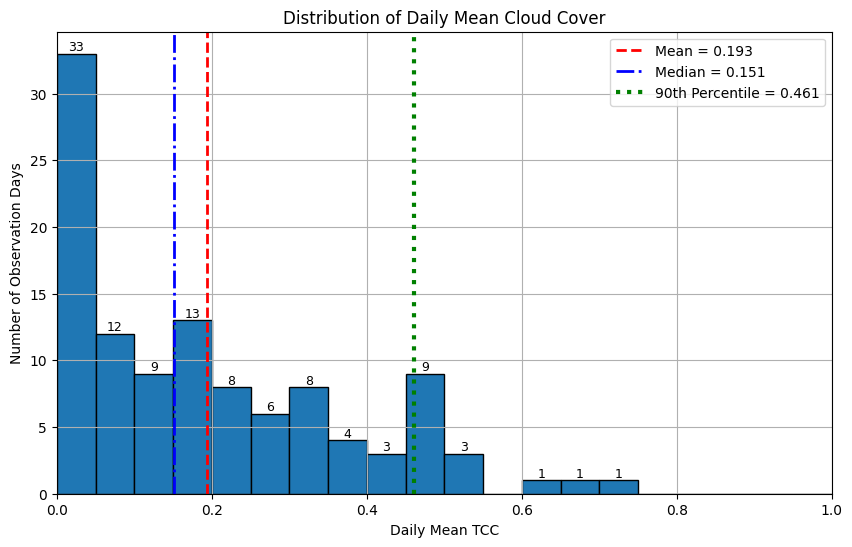

Mean TCC = 0.193
Median TCC = 0.151
90th Percentile TCC = 0.461


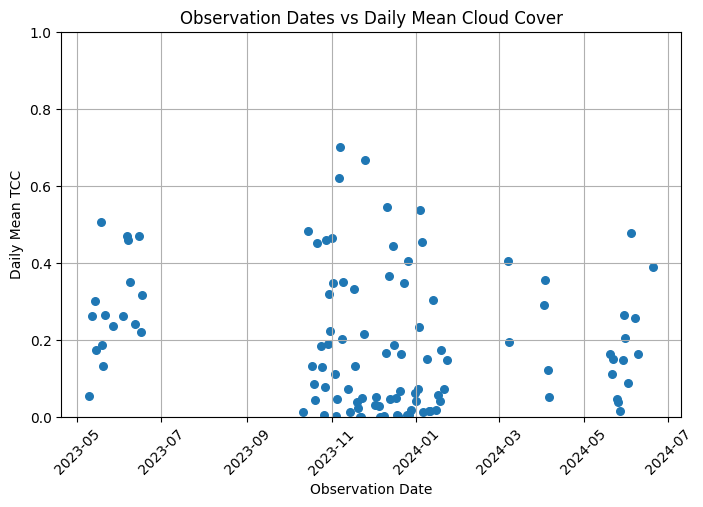

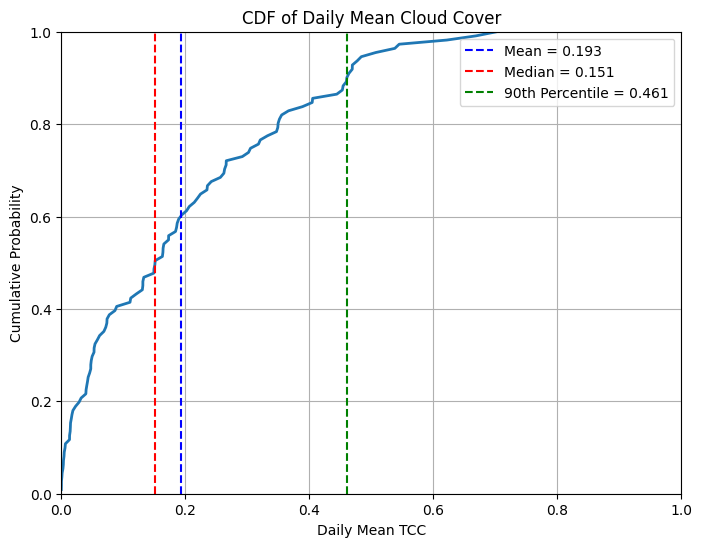


Cloud Cover Statistics
----------------------
Mean TCC             : 0.193
Median TCC           : 0.151
90th Percentile TCC  : 0.461


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ----------------------------
# Prepare dates
# ----------------------------

final_df['valid_time'] = pd.to_datetime(final_df['valid_time'])
df2['date'] = pd.to_datetime(df2['date'])

# ----------------------------
# Calculate daily mean TCC
# ----------------------------

daily_tcc = (
    final_df
    .groupby(final_df['valid_time'].dt.date)['tcc']
    .mean()
    .reset_index()
)

daily_tcc.columns = ['date', 'tcc']
daily_tcc['date'] = pd.to_datetime(daily_tcc['date'])

# ----------------------------
# Select observation dates
# ----------------------------

obs_tcc = (
    daily_tcc[daily_tcc['date'].isin(df2['date'])]
    .sort_values('date')
)

print("Number of observation dates:", len(obs_tcc))
# ==================================
# Histogram with statistics
# ==================================

# Calculate statistics
mean_tcc = obs_tcc['tcc'].mean()
median_tcc = obs_tcc['tcc'].median()
p90_tcc = obs_tcc['tcc'].quantile(0.90)

plt.figure(figsize=(10,6))

# Histogram
counts, bins, patches = plt.hist(
    obs_tcc['tcc'],
    bins=np.linspace(0, 1, 21),
    edgecolor='black'
)

# Add frequency numbers on bars
for count, patch in zip(counts, patches):
    if count > 0:
        plt.text(
            patch.get_x() + patch.get_width()/2,
            count,
            f"{int(count)}",
            ha='center',
            va='bottom',
            fontsize=9
        )

# Mean line
plt.axvline(
    mean_tcc,
    color='red',
    linestyle='--',
    linewidth=2,
    label=f"Mean = {mean_tcc:.3f}"
)

# Median line
plt.axvline(
    median_tcc,
    color='blue',
    linestyle='-.',
    linewidth=2,
    label=f"Median = {median_tcc:.3f}"
)

# 90th percentile line
plt.axvline(
    p90_tcc,
    color='green',
    linestyle=':',
    linewidth=3,
    label=f"90th Percentile = {p90_tcc:.3f}"
)

plt.xlabel("Daily Mean TCC")
plt.ylabel("Number of Observation Days")
plt.title("Distribution of Daily Mean Cloud Cover")
plt.xlim(0, 1)

plt.grid()
plt.legend()

plt.show()

# Print values
print(f"Mean TCC = {mean_tcc:.3f}")
print(f"Median TCC = {median_tcc:.3f}")
print(f"90th Percentile TCC = {p90_tcc:.3f}")
# ==================================
# 2. Scatter plot: Date vs TCC
# ==================================

plt.figure(figsize=(8,5))

plt.scatter(
    obs_tcc['date'],
    obs_tcc['tcc'],
    s=30
)

plt.xlabel("Observation Date")
plt.ylabel("Daily Mean TCC")
plt.title("Observation Dates vs Daily Mean Cloud Cover")

plt.xticks(rotation=45)
plt.ylim(0,1)
plt.grid(True)

plt.show()


# ==================================
# 3. CDF plot with statistics
# ==================================

sorted_tcc = np.sort(obs_tcc['tcc'])
cdf = np.arange(1, len(sorted_tcc)+1) / len(sorted_tcc)

mean_tcc = obs_tcc['tcc'].mean()
median_tcc = obs_tcc['tcc'].median()
p90_tcc = obs_tcc['tcc'].quantile(0.90)

plt.figure(figsize=(8,6))

plt.plot(sorted_tcc, cdf, linewidth=2)

plt.axvline(mean_tcc,color="blue", linestyle='--',
            label=f"Mean = {mean_tcc:.3f}")

plt.axvline(median_tcc,color="red", linestyle='--',
            label=f"Median = {median_tcc:.3f}")

plt.axvline(p90_tcc,color="green", linestyle='--',
            label=f"90th Percentile = {p90_tcc:.3f}")

plt.xlabel("Daily Mean TCC")
plt.ylabel("Cumulative Probability")
plt.title("CDF of Daily Mean Cloud Cover")

plt.xlim(0,1)
plt.ylim(0,1)
plt.grid(True)
plt.legend()

plt.show()


# ==================================
# Print statistics
# ==================================

print("\nCloud Cover Statistics")
print("----------------------")
print(f"Mean TCC             : {mean_tcc:.3f}")
print(f"Median TCC           : {median_tcc:.3f}")
print(f"90th Percentile TCC  : {p90_tcc:.3f}")

In [ ]:
import pandas as pd

# Convert time column to datetime
final_df["valid_time"] = pd.to_datetime(final_df["valid_time"])

# Create daily mean dataframe
daily_mean_df1 = (
    final_df
    .groupby(final_df["valid_time"].dt.date)["tcc"]
    .mean()
    .reset_index()
)

# Rename columns
daily_mean_df1.columns = ["date", "daily_mean_tcc"]

# Convert date column back to datetime
daily_mean_df1["date"] = pd.to_datetime(daily_mean_df1["date"])

# Show first few rows
print(daily_mean_df1.head())
print(daily_mean_df1.tail())

        date  daily_mean_tcc
0 2014-01-01        0.305521
1 2014-01-02        0.006197
2 2014-01-03        0.000018
3 2014-01-04        0.391147
4 2014-01-05        0.329508
           date  daily_mean_tcc
4529 2026-05-27        0.186447
4530 2026-05-28        0.350677
4531 2026-05-29        0.489948
4532 2026-05-30        0.965678
4533 2026-05-31        0.828760


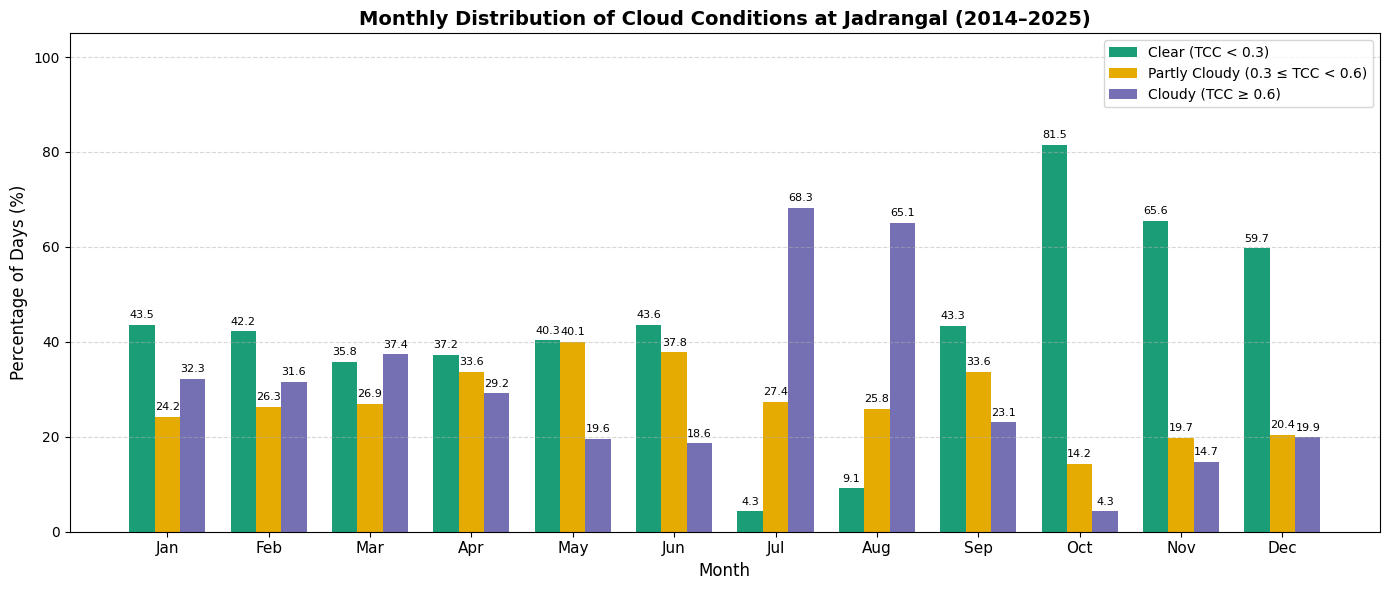

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Make sure date is datetime
daily_mean_df1["date"] = pd.to_datetime(daily_mean_df1["date"])

# Extract month
daily_mean_df1["Month"] = daily_mean_df1["date"].dt.month

# Function to classify cloud conditions
def cloud_category(tcc):
    if tcc < 0.3:
        return "Clear"
    elif tcc < 0.6:
        return "Partly Cloudy"
    else:
        return "Cloudy"

# Apply classification
daily_mean_df1["Condition"] = daily_mean_df1["daily_mean_tcc"].apply(cloud_category)

# Count days in each category per month
monthly_counts = (
    daily_mean_df1
    .groupby(["Month", "Condition"])
    .size()
    .unstack(fill_value=0)
)

# Ensure all categories exist
for col in ["Clear", "Partly Cloudy", "Cloudy"]:
    if col not in monthly_counts.columns:
        monthly_counts[col] = 0

# Convert to percentage of days
monthly_percent = monthly_counts.div(
    monthly_counts.sum(axis=1), axis=0
) * 100

# Ensure months 1–12 exist
monthly_percent = monthly_percent.reindex(range(1, 13), fill_value=0)

# Ensure order
monthly_percent = monthly_percent[
    ["Clear", "Partly Cloudy", "Cloudy"]
]

# Month labels
months = ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
          "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

# Plot
fig, ax = plt.subplots(figsize=(14, 6))

x = np.arange(12)
width = 0.25

# Publication-quality colors
bars1 = ax.bar(x - width, monthly_percent["Clear"],
               width, label="Clear (TCC < 0.3)",
               color="#1b9e77")

bars2 = ax.bar(x, monthly_percent["Partly Cloudy"],
               width, label="Partly Cloudy (0.3 ≤ TCC < 0.6)",
               color="#e6ab02")

bars3 = ax.bar(x + width, monthly_percent["Cloudy"],
               width, label="Cloudy (TCC ≥ 0.6)",
               color="#7570b3")
# Add values above bars
for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height = bar.get_height()
        if height > 0:
            ax.text(
                bar.get_x() + bar.get_width()/2,
                height + 1,
                f"{height:.1f}",
                ha="center",
                va="bottom",
                fontsize=8
            )

# Formatting
ax.set_xticks(x)
ax.set_xticklabels(months, fontsize=11)
ax.set_xlabel("Month", fontsize=12)
ax.set_ylabel("Percentage of Days (%)", fontsize=12)

ax.set_title(
    "Monthly Distribution of Cloud Conditions at Jadrangal (2014–2025)",
    fontsize=14,
    weight="bold"
)

ax.set_ylim(0, 105)
ax.grid(axis="y", linestyle="--", alpha=0.5)
ax.legend(fontsize=10)

plt.tight_layout()
plt.show()

[2014 2015 2016 2017 2018 2019 2020 2021 2022 2023 2024 2025]


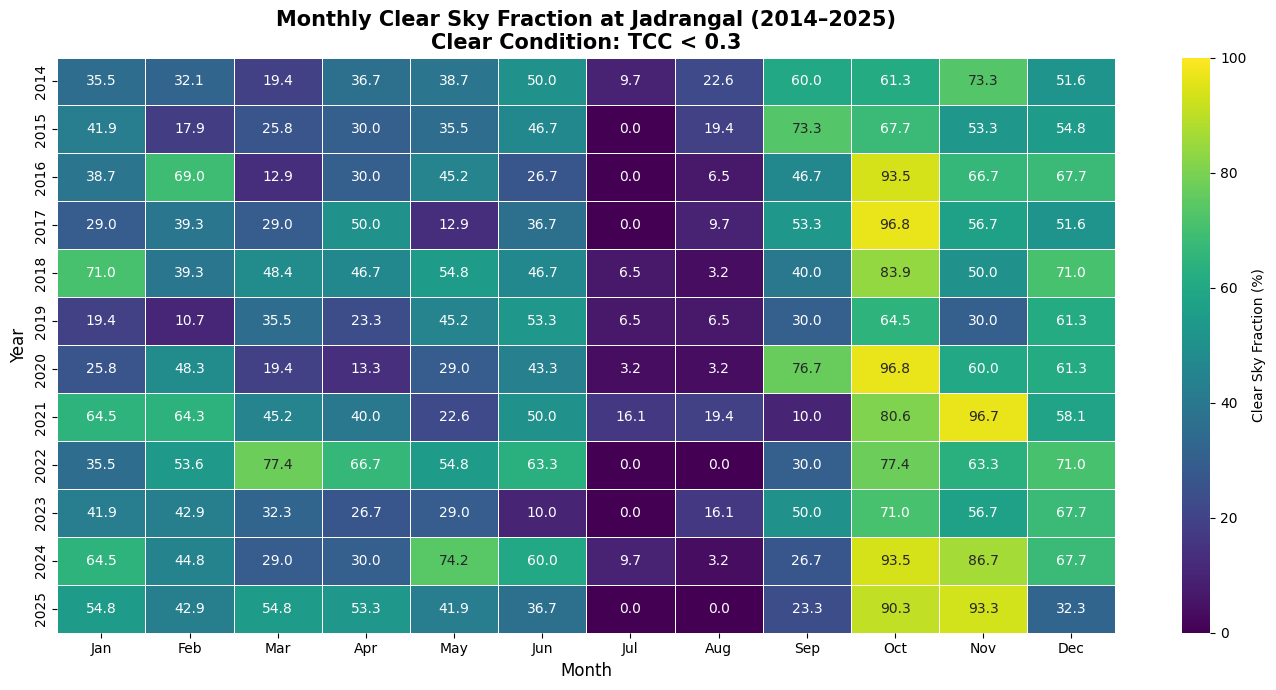

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure date format
daily_mean_df1["date"] = pd.to_datetime(daily_mean_df1["date"])
# Remove 2026 data
daily_mean_df1 = daily_mean_df1[daily_mean_df1["date"].dt.year != 2026]

# Check years present
print(daily_mean_df1["date"].dt.year.unique())

# Extract year and month
daily_mean_df1["Year"] = daily_mean_df1["date"].dt.year
daily_mean_df1["Month"] = daily_mean_df1["date"].dt.month

# Define clear sky condition
daily_mean_df1["Clear"] = (daily_mean_df1["daily_mean_tcc"] < 0.3).astype(int)

# Calculate monthly clear sky fraction (%)
heatmap_data = (
    daily_mean_df1
    .groupby(["Year", "Month"])["Clear"]
    .mean()
    .unstack() * 100
)

# Month names
months = ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
          "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

heatmap_data.columns = months

# Plot heatmap
plt.figure(figsize=(14, 7))

sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".1f",
    cmap="viridis",
    linewidths=0.5,
    cbar_kws={"label": "Clear Sky Fraction (%)"},
    vmin=0,
    vmax=100
)

plt.title(
    "Monthly Clear Sky Fraction at Jadrangal (2014–2025)\n"
    "Clear Condition: TCC < 0.3",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Month", fontsize=12)
plt.ylabel("Year", fontsize=12)

plt.tight_layout()
plt.show()

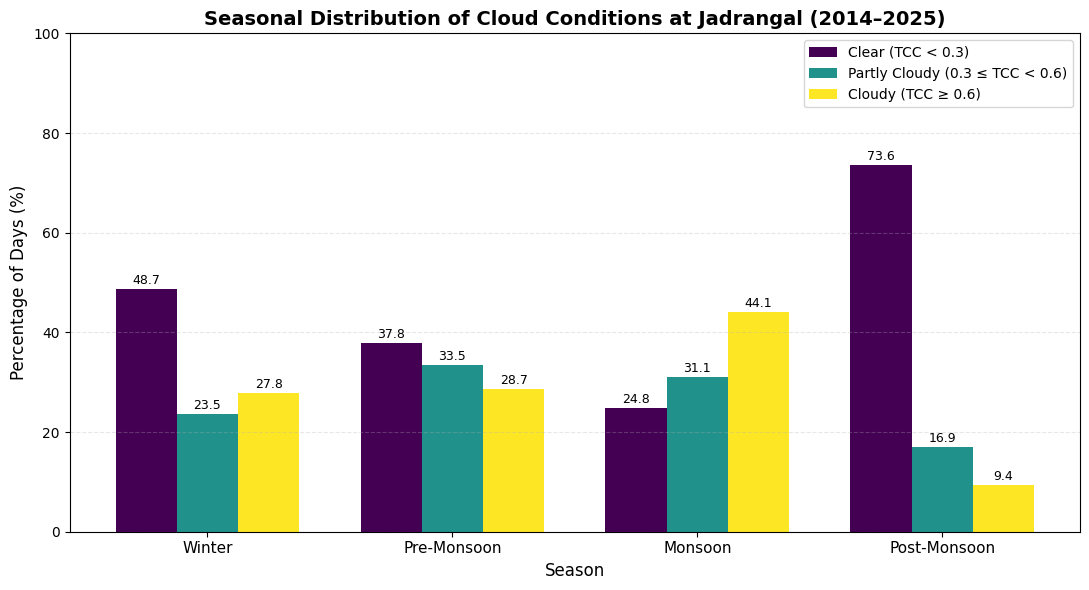

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Ensure date is datetime
daily_mean_df1["date"] = pd.to_datetime(daily_mean_df1["date"])

# Define seasons (IMD classification)
def get_season(month):
    if month in [12, 1, 2]:
        return "Winter"
    elif month in [3, 4, 5]:
        return "Pre-Monsoon"
    elif month in [6, 7, 8, 9]:
        return "Monsoon"
    else:
        return "Post-Monsoon"

# Assign seasons
daily_mean_df1["Season"] = daily_mean_df1["date"].dt.month.apply(get_season)

# Classify cloud condition
def cloud_category(tcc):
    if tcc < 0.3:
        return "Clear"
    elif tcc < 0.6:
        return "Partly Cloudy"
    else:
        return "Cloudy"

daily_mean_df1["Condition"] = daily_mean_df1["daily_mean_tcc"].apply(cloud_category)

# Count days in each category for each season
season_counts = (
    daily_mean_df1
    .groupby(["Season", "Condition"])
    .size()
    .unstack(fill_value=0)
)

# Arrange season order
season_order = ["Winter", "Pre-Monsoon", "Monsoon", "Post-Monsoon"]
season_counts = season_counts.reindex(season_order)

# Convert to percentage
season_cloud_percent = (
    season_counts.div(season_counts.sum(axis=1), axis=0)
    * 100
)

# ---------------- Plot ----------------

seasons = season_cloud_percent.index
x = np.arange(len(seasons))
width = 0.25

plt.figure(figsize=(11, 6))

# Bars
plt.bar(
    x - width,
    season_cloud_percent["Clear"],
    width,
    label="Clear (TCC < 0.3)",
    color="#440154"
)

plt.bar(
    x,
    season_cloud_percent["Partly Cloudy"],
    width,
    label="Partly Cloudy (0.3 ≤ TCC < 0.6)",
    color="#21918c"
)

plt.bar(
    x + width,
    season_cloud_percent["Cloudy"],
    width,
    label="Cloudy (TCC ≥ 0.6)",
    color="#fde725"
)

# Add values above bars
for i in range(len(seasons)):
    plt.text(
        x[i]-width,
        season_cloud_percent["Clear"].iloc[i] + 1,
        f'{season_cloud_percent["Clear"].iloc[i]:.1f}',
        ha="center",
        fontsize=9
    )

    plt.text(
        x[i],
        season_cloud_percent["Partly Cloudy"].iloc[i] + 1,
        f'{season_cloud_percent["Partly Cloudy"].iloc[i]:.1f}',
        ha="center",
        fontsize=9
    )

    plt.text(
        x[i]+width,
        season_cloud_percent["Cloudy"].iloc[i] + 1,
        f'{season_cloud_percent["Cloudy"].iloc[i]:.1f}',
        ha="center",
        fontsize=9
    )

# Formatting
plt.xticks(x, seasons, fontsize=11)

plt.ylabel("Percentage of Days (%)", fontsize=12)
plt.xlabel("Season", fontsize=12)

plt.title(
    "Seasonal Distribution of Cloud Conditions at Jadrangal (2014–2025)",
    fontsize=14,
    weight="bold"
)

plt.ylim(0, 100)

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.3
)

plt.legend()

plt.tight_layout()
plt.show()

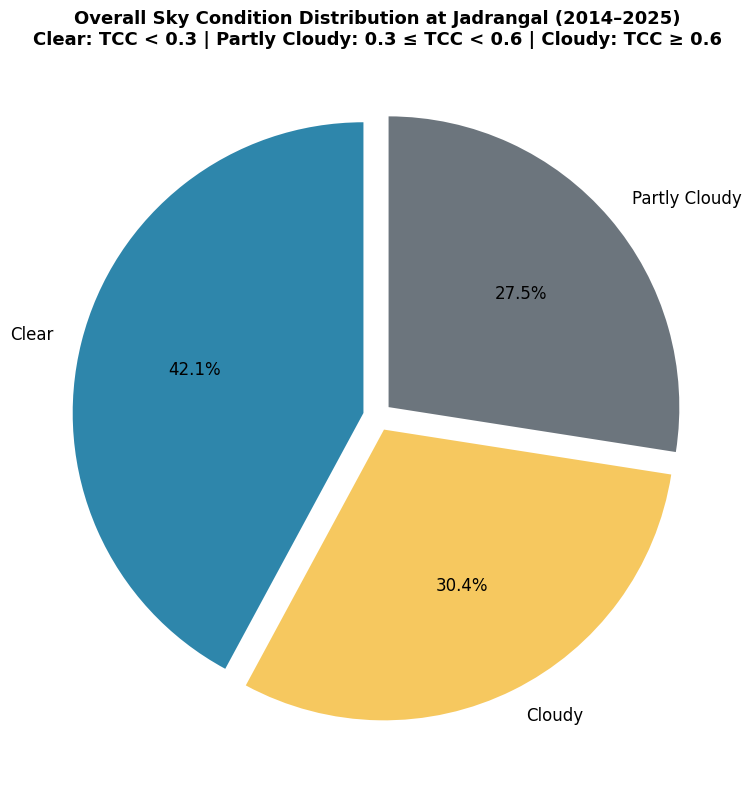

In [ ]:
import matplotlib.pyplot as plt

# Calculate overall percentage
overall_cloud = (
    daily_mean_df1["Condition"]
    .value_counts(normalize=True)
    * 100
)

# Define colors according to category
color_map = {
    "Clear": "cyan",
    "Partly Cloudy": "orange",
    "Cloudy": "green"
}

colors = [color_map[label] for label in overall_cloud.index]

# Pie chart
plt.figure(figsize=(8, 8))

plt.pie(
    overall_cloud.values,
    labels=overall_cloud.index,
    colors = ["#2E86AB", "#F6C85F", "#6C757D"],
    autopct="%1.1f%%",
    startangle=90,
    explode=[0.05, 0.05, 0.05],
    textprops={"fontsize": 12}
)

plt.title(
    "Overall Sky Condition Distribution at Jadrangal (2014–2025)\n"
    "Clear: TCC < 0.3 | Partly Cloudy: 0.3 ≤ TCC < 0.6 | Cloudy: TCC ≥ 0.6",
    fontsize=13,
    weight="bold"
)

plt.tight_layout()
plt.show()

    Year  Clear_Night
0   2014          149
1   2015          142
2   2016          153
3   2017          141
4   2018          171
5   2019          118
6   2020          146
7   2021          172
8   2022          180
9   2023          135
10  2024          180
11  2025          159
Estimated clear nights = 153.8 ± 19.2 nights/year


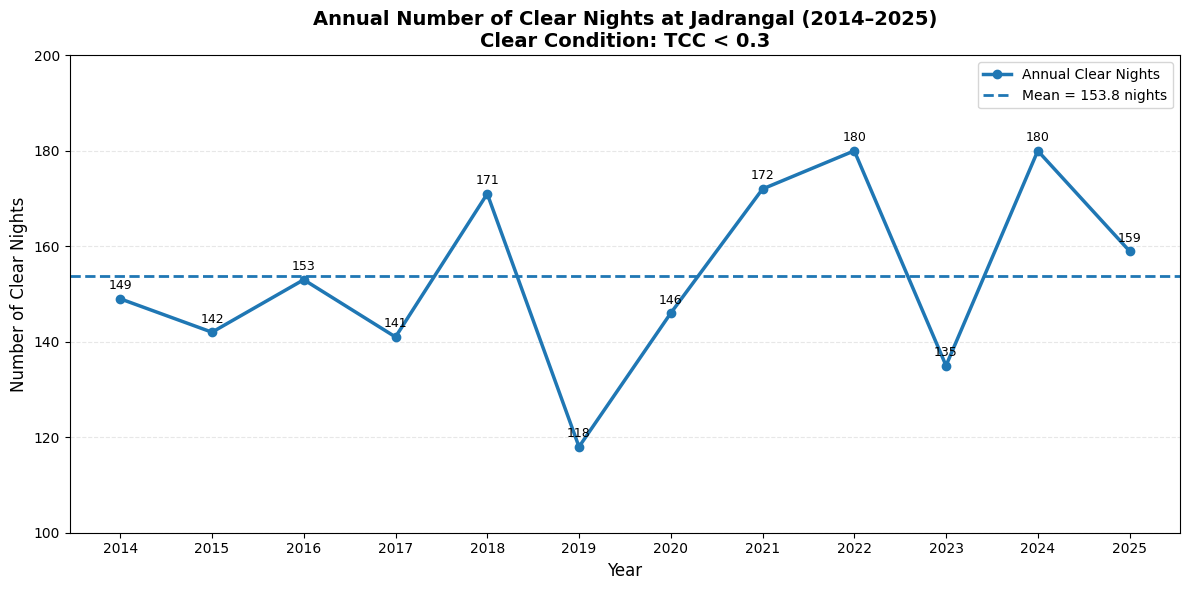

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Ensure date is datetime
daily_mean_df1["date"] = pd.to_datetime(daily_mean_df1["date"])

# Extract year
daily_mean_df1["Year"] = daily_mean_df1["date"].dt.year

# Define clear nights (TCC < 0.3)
daily_mean_df1["Clear_Night"] = (
    daily_mean_df1["daily_mean_tcc"] < 0.3
).astype(int)

# Count clear nights per year
annual_clear_nights = (
    daily_mean_df1
    .groupby("Year")["Clear_Night"]
    .sum()
    .reset_index()
)

print(annual_clear_nights)

# Calculate mean and standard deviation
mean_clear = annual_clear_nights["Clear_Night"].mean()
std_clear = annual_clear_nights["Clear_Night"].std()

print(
    f"Estimated clear nights = {mean_clear:.1f} ± {std_clear:.1f} nights/year"
)

# ---------------- Plot ----------------

plt.figure(figsize=(12, 6))

plt.plot(
    annual_clear_nights["Year"],
    annual_clear_nights["Clear_Night"],
    marker="o",
    linewidth=2.5,
    label="Annual Clear Nights"
)

# Add values on points
for x, y in zip(
    annual_clear_nights["Year"],
    annual_clear_nights["Clear_Night"]
):
    plt.text(
        x,
        y + 2,
        f"{int(y)}",
        ha="center",
        fontsize=9
    )

# Mean line
plt.axhline(
    mean_clear,
    linestyle="--",
    linewidth=2,
    label=f"Mean = {mean_clear:.1f} nights"
)

# Formatting
plt.xlabel("Year", fontsize=12)
plt.ylabel("Number of Clear Nights", fontsize=12)

plt.title(
    "Annual Number of Clear Nights at Jadrangal (2014–2025)\n"
    "Clear Condition: TCC < 0.3",
    fontsize=14,
    weight="bold"
)

plt.xticks(annual_clear_nights["Year"])

# Start y-axis from 100
plt.ylim(
    100,
    annual_clear_nights["Clear_Night"].max() + 20
)

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.3
)

plt.legend()

plt.tight_layout()
plt.show()

Estimated clear nights = 153.8 ± 19.2 nights/year


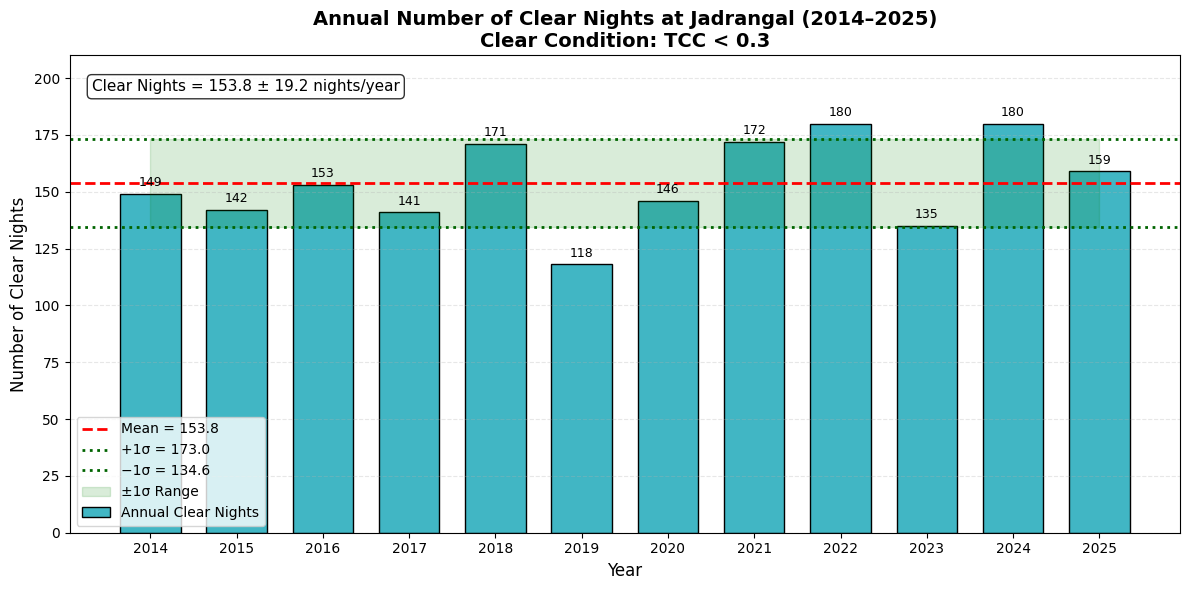

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ==============================
# Calculate statistics
# ==============================

mean_clear = annual_clear_nights["Clear_Night"].mean()
std_clear = annual_clear_nights["Clear_Night"].std()

print(f"Estimated clear nights = {mean_clear:.1f} ± {std_clear:.1f} nights/year")

# ==============================
# Bar Chart
# ==============================

plt.figure(figsize=(12, 6))

bars = plt.bar(
    annual_clear_nights["Year"],
    annual_clear_nights["Clear_Night"],
    color="#41b6c4",
    edgecolor="black",
    width=0.7,
    label="Annual Clear Nights"
)

# Values above bars
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 2,
        f"{int(height)}",
        ha="center",
        va="bottom",
        fontsize=9
    )

# Mean line
plt.axhline(
    mean_clear,
    color="red",
    linestyle="--",
    linewidth=2,
    label=f"Mean = {mean_clear:.1f}"
)

# +1 sigma line
plt.axhline(
    mean_clear + std_clear,
    color="darkgreen",
    linestyle=":",
    linewidth=2,
    label=f"+1σ = {mean_clear + std_clear:.1f}"
)

# -1 sigma line
plt.axhline(
    mean_clear - std_clear,
    color="darkgreen",
    linestyle=":",
    linewidth=2,
    label=f"−1σ = {mean_clear - std_clear:.1f}"
)

# Optional shaded ±1σ region
plt.fill_between(
    annual_clear_nights["Year"],
    mean_clear - std_clear,
    mean_clear + std_clear,
    color="green",
    alpha=0.15,
    label="±1σ Range"
)

plt.xlabel("Year", fontsize=12)
plt.ylabel("Number of Clear Nights", fontsize=12)

plt.title(
    "Annual Number of Clear Nights at Jadrangal (2014–2025)\n"
    "Clear Condition: TCC < 0.3",
    fontsize=14,
    weight="bold"
)

plt.text(
    0.02, 0.95,
    f"Clear Nights = {mean_clear:.1f} ± {std_clear:.1f} nights/year",
    transform=plt.gca().transAxes,
    fontsize=11,
    verticalalignment='top',
    bbox=dict(
        boxstyle="round",
        facecolor="white",
        alpha=0.8,
        edgecolor="black"
    )
)
plt.xticks(annual_clear_nights["Year"])
plt.ylim(0, annual_clear_nights["Clear_Night"].max() + 30)

plt.grid(axis="y", linestyle="--", alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

Yearly Clear Sky Availability:
    Year  Clear_Percentage
0   2014         40.821918
1   2015         38.904110
2   2016         41.803279
3   2017         38.630137
4   2018         46.849315
5   2019         32.328767
6   2020         39.890710
7   2021         47.123288
8   2022         49.315068
9   2023         36.986301
10  2024         49.180328
11  2025         43.561644

Overall Result:
Clear Sky Availability = 42.12 ± 5.24 %


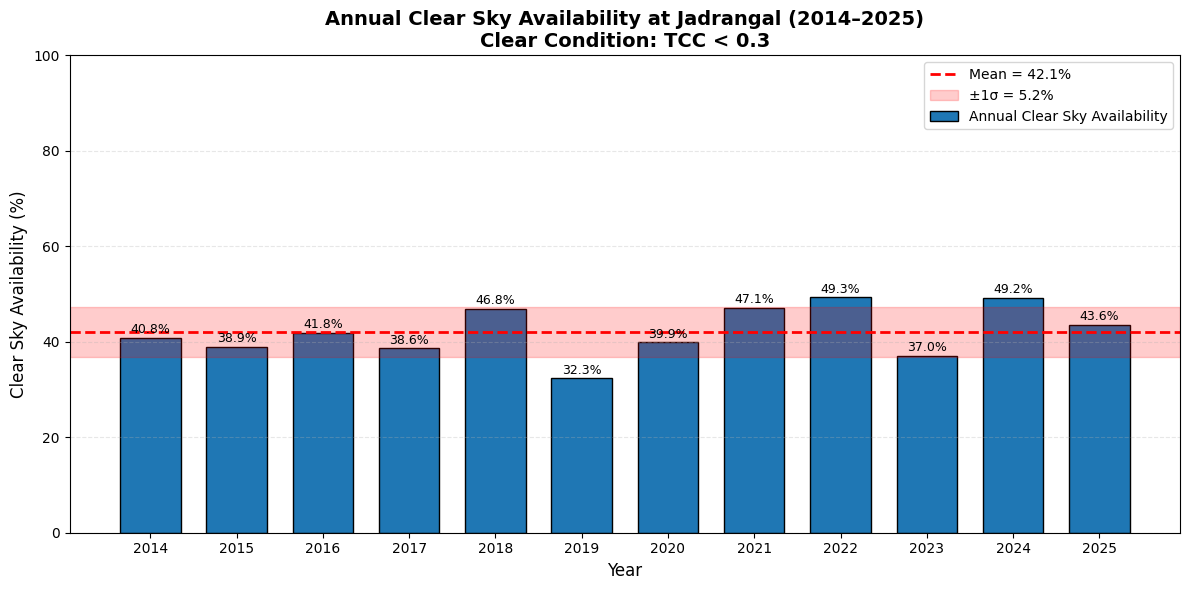

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Make sure date is datetime
daily_mean_df1["date"] = pd.to_datetime(daily_mean_df1["date"])

# Extract year
daily_mean_df1["Year"] = daily_mean_df1["date"].dt.year

# Define clear condition
daily_mean_df1["Clear"] = (daily_mean_df1["daily_mean_tcc"] < 0.3).astype(int)

# Calculate yearly clear sky availability (%)
annual_clear_percent = (
    daily_mean_df1
    .groupby("Year")["Clear"]
    .mean()
    * 100
).reset_index()

annual_clear_percent.columns = ["Year", "Clear_Percentage"]

# Calculate mean and standard deviation
mean_clear = annual_clear_percent["Clear_Percentage"].mean()
sigma_clear = annual_clear_percent["Clear_Percentage"].std()

# Print final result
print("Yearly Clear Sky Availability:")
print(annual_clear_percent)

print("\nOverall Result:")
print(
    f"Clear Sky Availability = {mean_clear:.2f} ± {sigma_clear:.2f} %"
)

# Plot
plt.figure(figsize=(12,6))

bars = plt.bar(
    annual_clear_percent["Year"],
    annual_clear_percent["Clear_Percentage"],
    width=0.7,
    edgecolor="black",
    label="Annual Clear Sky Availability"
)

# Add values on bars
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 1,
        f"{height:.1f}%",
        ha="center",
        fontsize=9
    )

# Mean line
plt.axhline(
    mean_clear,
    color="red",
    linestyle="--",
    linewidth=2,
    label=f"Mean = {mean_clear:.1f}%"
)

# ± sigma region
plt.axhspan(
    mean_clear - sigma_clear,
    mean_clear + sigma_clear,
    color="red",
    alpha=0.2,
    label=f"±1σ = {sigma_clear:.1f}%"
)

plt.xlabel("Year", fontsize=12)
plt.ylabel("Clear Sky Availability (%)", fontsize=12)

plt.title(
    "Annual Clear Sky Availability at Jadrangal (2014–2025)\n"
    "Clear Condition: TCC < 0.3",
    fontsize=14,
    weight="bold"
)

plt.xticks(annual_clear_percent["Year"])
plt.ylim(0, 100)

plt.grid(axis="y", linestyle="--", alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
####################################################
#########################################################
##############################################################
######################################################################

In [ ]:
###################################
###################################################
###############################################
######################################################
#####################################################
##############################################
####################################################################

In [ ]:
site14_15 = df14_15[
    (df14_15["latitude"] == 32.25) &
    (df14_15["longitude"] == 76.50)
]

site16_17 = df16_17[
    (df16_17["latitude"] == 32.25) &
    (df16_17["longitude"] == 76.50)
]

site18_19 = df18_19[
    (df18_19["latitude"] == 32.25) &
    (df18_19["longitude"] == 76.50)
]

site20_21 = df20_21[
    (df20_21["latitude"] == 32.25) &
    (df20_21["longitude"] == 76.50)
]

site22_25 = df22_25[
    (df22_25["latitude"] == 32.25) &
    (df22_25["longitude"] == 76.50)
]

site23_24 = df23_24[
    (df23_24["latitude"] == 32.25) &
    (df23_24["longitude"] == 76.50)
]

site26 = df26[
    (df26["latitude"] == 32.25) &
    (df26["longitude"] == 76.50)
]

In [ ]:
import pandas as pd

site = pd.concat([
    site14_15,
    site16_17,
    site18_19,
    site20_21,
    site22_25,
    site23_24,
    site26
], ignore_index=True)

In [ ]:
site["valid_time"] = pd.to_datetime(site["valid_time"])

site["year"] = site["valid_time"].dt.year
site["month"] = site["valid_time"].dt.month
site["date"] = site["valid_time"].dt.date

In [ ]:
import pandas as pd

site["valid_time"] = pd.to_datetime(site["valid_time"])

In [ ]:
site["date"] = site["valid_time"].dt.date

In [ ]:
daily_tcc = (
    site.groupby("date")["tcc"]
    .mean()
    .reset_index()
)

daily_tcc.rename(columns={"tcc": "daily_tcc"}, inplace=True)

print(daily_tcc.head())

         date  daily_tcc
0  2014-01-01   0.236917
1  2014-01-02   0.004640
2  2014-01-03   0.000025
3  2014-01-04   0.395345
4  2014-01-05   0.382636


In [ ]:
daily_tcc["date"] = pd.to_datetime(daily_tcc["date"])

daily_tcc["year"] = daily_tcc["date"].dt.year
daily_tcc["month"] = daily_tcc["date"].dt.month

In [ ]:
def classify_cloud(tcc):
    if tcc < 0.3:
        return "Clear"
    elif tcc < 0.6:
        return "Partly Cloudy"
    else:
        return "Cloudy"

daily_tcc["cloud_condition"] = daily_tcc["daily_tcc"].apply(classify_cloud)



In [ ]:
daily_tcc

,date,daily_tcc,year,month,cloud_condition
0,2014-01-01,0.236917,2014,1,Clear
1,2014-01-02,0.004640,2014,1,Clear
2,2014-01-03,0.000025,2014,1,Clear
3,2014-01-04,0.395345,2014,1,Partly Cloudy
4,2014-01-05,0.382636,2014,1,Partly Cloudy
...,...,...,...,...,...
4529,2026-05-27,0.208257,2026,5,Clear
4530,2026-05-28,0.375008,2026,5,Partly Cloudy
4531,2026-05-29,0.544153,2026,5,Partly Cloudy
4532,2026-05-30,0.974106,2026,5,Cloudy


In [ ]:
# Ensure date is datetime
daily_tcc["date"] = pd.to_datetime(daily_tcc["date"])

# Keep only data before 2026
daily_tcc_filtered = daily_tcc[daily_tcc["date"].dt.year < 2026]

In [ ]:
daily_tcc_filtered["month"] = daily_tcc_filtered["date"].dt.month

monthly_cloud = (
    daily_tcc_filtered
    .groupby(["month", "cloud_condition"])
    .size()
    .unstack(fill_value=0)
)

monthly_cloud_percent = (
    monthly_cloud.div(monthly_cloud.sum(axis=1), axis=0) * 100
)

/tmp/ipykernel_5538/3678587741.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  daily_tcc_filtered["month"] = daily_tcc_filtered["date"].dt.month


In [ ]:
def classify_cloud(tcc):
    if tcc < 0.3:
        return "Clear"
    elif 0.3 <= tcc < 0.6:
        return "Partly Cloudy"
    else:
        return "Cloudy"
daily_tcc["cloud_condition"] = daily_tcc["daily_tcc"].apply(classify_cloud)

In [ ]:
monthly_cloud = (
    daily_tcc.groupby(["month", "cloud_condition"])
    .size()
    .unstack(fill_value=0)

)

monthly_cloud_percent = (
    monthly_cloud.div(monthly_cloud.sum(axis=1), axis=0)
    * 100
)

print(monthly_cloud_percent)

cloud_condition      Clear     Cloudy  Partly Cloudy
month                                               
1                45.409429  31.017370      23.573201
2                43.869210  32.152589      23.978202
3                32.506203  39.702233      27.791563
4                33.076923  31.282051      35.641026
5                35.483871  23.076923      41.439206
6                35.277778  24.166667      40.555556
7                 1.612903  75.806452      22.580645
8                 7.258065  66.397849      26.344086
9                35.000000  25.000000      40.000000
10               76.344086   4.838710      18.817204
11               64.722222  14.722222      20.555556
12               58.333333  20.430108      21.236559


In [ ]:
daily_tcc["clear_day"] = daily_tcc["daily_tcc"] < 0.3


In [ ]:
monthly_cloud = (
    daily_tcc.groupby(["month", "cloud_condition"])
    .size()
    .unstack(fill_value=0)
)

monthly_cloud_percent = (
    monthly_cloud.div(monthly_cloud.sum(axis=1), axis=0)
    * 100
)

monthly_cloud_percent = monthly_cloud_percent.reindex(range(1, 13))

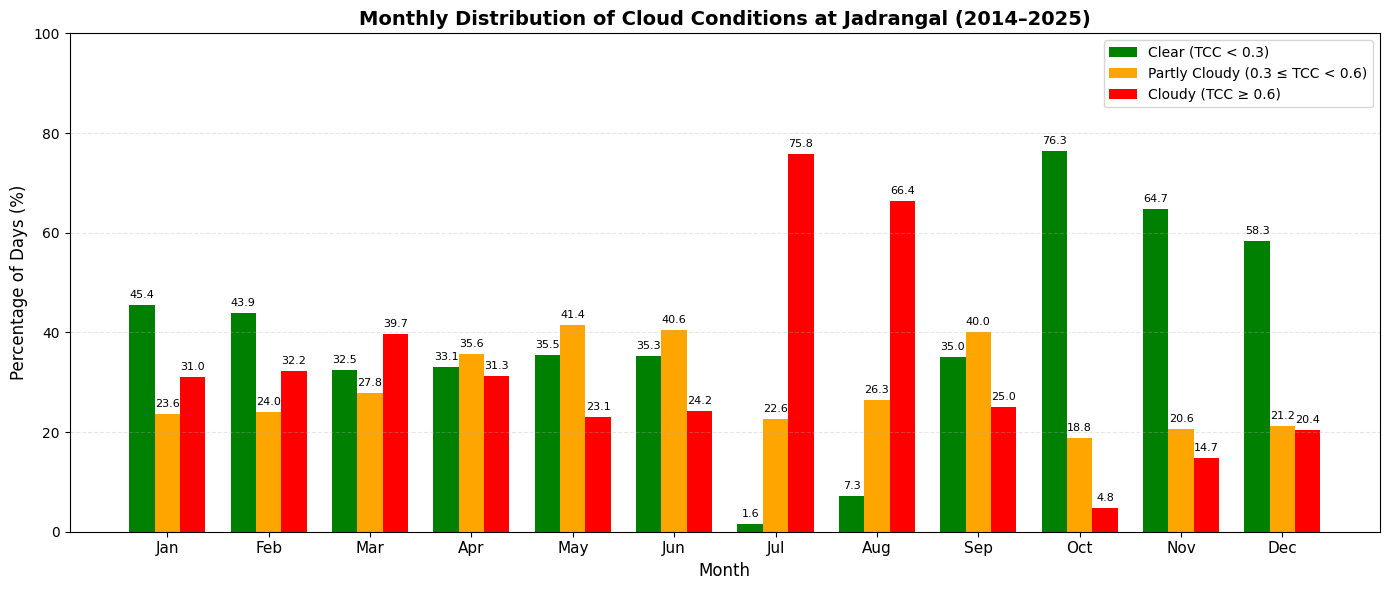

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

months = [
    "Jan","Feb","Mar","Apr","May","Jun",
    "Jul","Aug","Sep","Oct","Nov","Dec"
]

x = np.arange(len(months))
width = 0.25

plt.figure(figsize=(14,6))

# Bars
# Bars
clear = plt.bar(
    x - width,
    monthly_cloud_percent["Clear"],
    width,
    label="Clear (TCC < 0.3)",
    color="green"
)

partly = plt.bar(
    x,
    monthly_cloud_percent["Partly Cloudy"],
    width,
    label="Partly Cloudy (0.3 ≤ TCC < 0.6)",
    color="orange"
)

cloudy = plt.bar(
    x + width,
    monthly_cloud_percent["Cloudy"],
    width,
    label="Cloudy (TCC ≥ 0.6)",
    color="red"
)


# Add percentage labels on bars
for bars in [clear, partly, cloudy]:
    for bar in bars:
        height = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width()/2,
            height + 1,
            f"{height:.1f}",
            ha="center",
            va="bottom",
            fontsize=8
        )


plt.xticks(x, months, fontsize=11)

plt.ylabel("Percentage of Days (%)", fontsize=12)
plt.xlabel("Month", fontsize=12)

plt.title(
    "Monthly Distribution of Cloud Conditions at Jadrangal (2014–2025)",
    fontsize=14,
    weight="bold"
)

plt.ylim(0, 100)

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.3
)

plt.legend(
    fontsize=10,
    loc="upper right"
)

plt.tight_layout()
plt.show()

In [ ]:
clear_heatmap = (
    daily_tcc
    .groupby(["year", "month"])["clear_day"]
    .mean()
    .unstack()
)

print(clear_heatmap)

month        1         2         3         4         5         6         7   \
year                                                                          
2014   0.387097  0.357143  0.225806  0.333333  0.290323  0.466667  0.000000   
2015   0.451613  0.178571  0.225806  0.266667  0.354839  0.300000  0.000000   
2016   0.419355  0.655172  0.096774  0.266667  0.387097  0.166667  0.000000   
2017   0.290323  0.392857  0.258065  0.500000  0.096774  0.266667  0.000000   
2018   0.709677  0.392857  0.483871  0.466667  0.548387  0.366667  0.064516   
2019   0.193548  0.142857  0.322581  0.233333  0.419355  0.533333  0.064516   
2020   0.258065  0.482759  0.193548  0.100000  0.290323  0.366667  0.000000   
2021   0.677419  0.607143  0.419355  0.333333  0.225806  0.266667  0.032258   
2022   0.354839  0.500000  0.774194  0.600000  0.354839  0.633333  0.000000   
2023   0.451613  0.392857  0.290323  0.266667  0.290323  0.033333  0.000000   
2024   0.709677  0.482759  0.258065  0.166667  0.677

In [ ]:
clear_heatmap = clear_heatmap * 100

In [ ]:
clear_heatmap = clear_heatmap.drop(2026, errors="ignore")

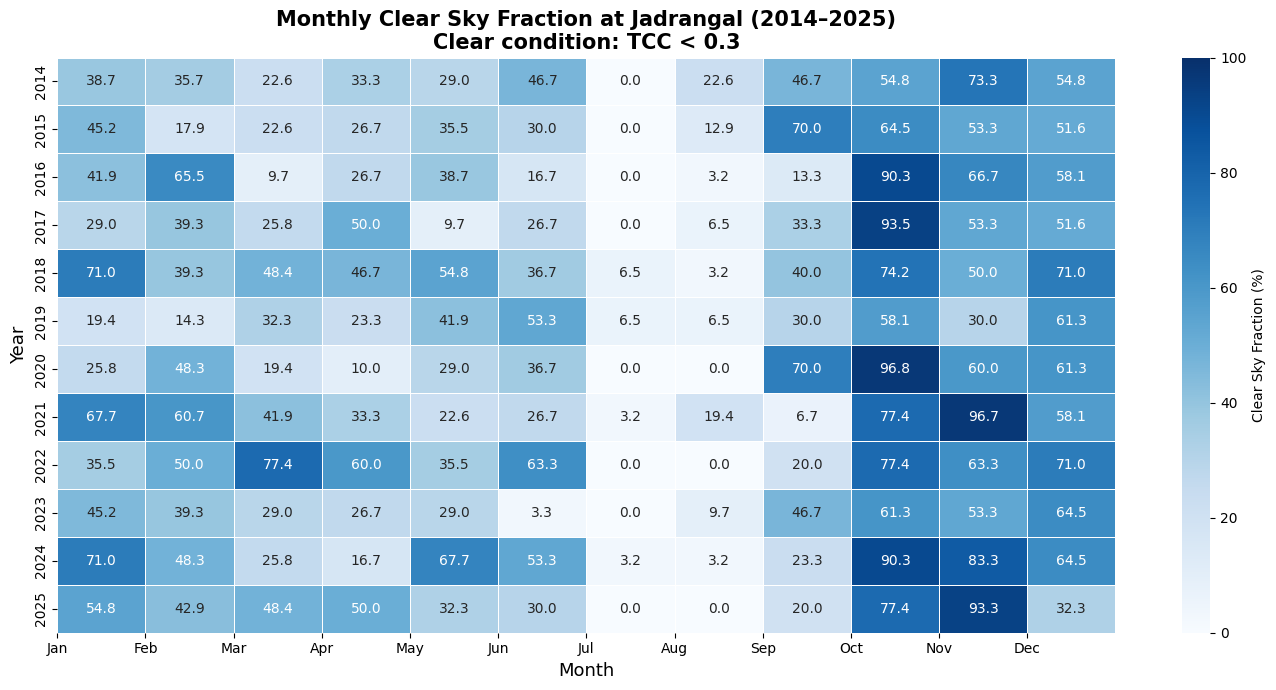

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

months = [
    "Jan", "Feb", "Mar", "Apr",
    "May", "Jun", "Jul", "Aug",
    "Sep", "Oct", "Nov", "Dec"
]

plt.figure(figsize=(14,7))

sns.heatmap(
    clear_heatmap,
    cmap="Blues",
    annot=True,
    fmt=".1f",
    vmin=0,
    vmax=100,
    linewidths=0.5,
    cbar_kws={
        "label": "Clear Sky Fraction (%)"
    }
)

plt.xticks(
    ticks=range(12),
    labels=months,
    rotation=0
)

plt.xlabel("Month", fontsize=13)
plt.ylabel("Year", fontsize=13)

plt.title(
    "Monthly Clear Sky Fraction at Jadrangal (2014–2025)\n"
    "Clear condition: TCC < 0.3",
    fontsize=15,
    weight="bold"
)

plt.tight_layout()

plt.show()

In [ ]:
annual_clear_days = (
    daily_tcc[daily_tcc["cloud_condition"] == "Clear"]
    .groupby("year")
    .size()
    .reset_index(name="clear_days")
)
# Exclude 2026
annual_clear_days = annual_clear_days[
    annual_clear_days["year"] < 2026
]

print(annual_clear_days)

    year  clear_days
0   2014         139
1   2015         131
2   2016         131
3   2017         127
4   2018         165
5   2019         115
6   2020         139
7   2021         156
8   2022         168
9   2023         124
10  2024         168
11  2025         146


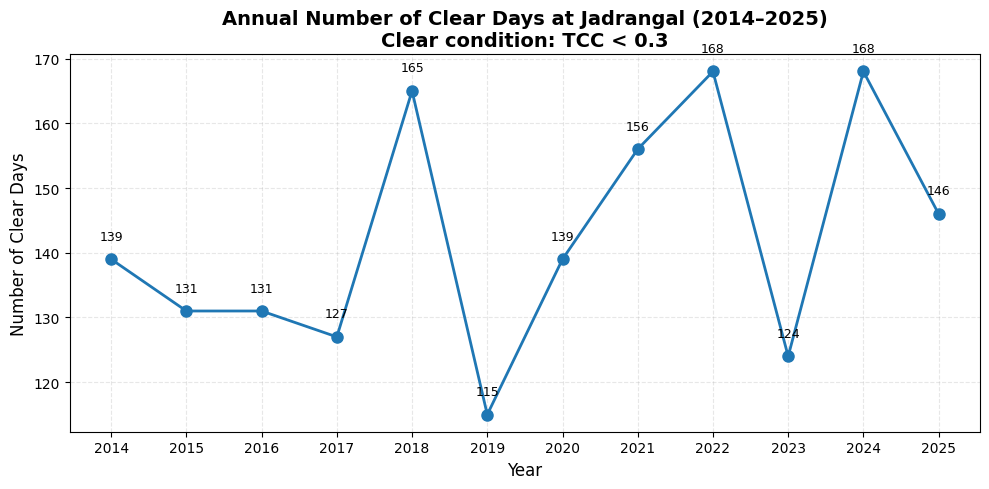

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.plot(
    annual_clear_days["year"],
    annual_clear_days["clear_days"],
    marker="o",
    linewidth=2,
    markersize=8
)

# Add values above each point
for x, y in zip(
    annual_clear_days["year"],
    annual_clear_days["clear_days"]
):
    plt.text(
        x,
        y + 3,
        str(y),
        ha="center",
        fontsize=9
    )

plt.xlabel("Year", fontsize=12)
plt.ylabel("Number of Clear Days", fontsize=12)

plt.title(
    "Annual Number of Clear Days at Jadrangal (2014–2025)\n"
    "Clear condition: TCC < 0.3",
    fontsize=14,
    weight="bold"
)

plt.xticks(annual_clear_days["year"])
plt.grid(True, linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
def get_season(month):
    if month in [1, 2]:
        return "Winter"
    elif month in [3, 4, 5]:
        return "Pre-Monsoon"
    elif month in [6, 7, 8, 9]:
        return "Southwest Monsoon"
    else:
        return "Post-Monsoon"


daily_tcc["season"] = daily_tcc["month"].apply(get_season)

In [ ]:
season_cloud = (
    daily_tcc.groupby(["season", "cloud_condition"])
    .size()
    .unstack(fill_value=0)
)

season_cloud_percent = (
    season_cloud.div(season_cloud.sum(axis=1), axis=0)
    * 100
)

season_order = [
    "Winter",
    "Pre-Monsoon",
    "Southwest Monsoon",
    "Post-Monsoon"
]

season_cloud_percent = season_cloud_percent.loc[season_order]

print(season_cloud_percent.round(2))

cloud_condition    Clear  Cloudy  Partly Cloudy
season                                         
Winter             44.68   31.56          23.77
Pre-Monsoon        33.70   31.35          34.95
Southwest Monsoon  19.54   48.22          32.24
Post-Monsoon       66.49   13.32          20.20


/tmp/ipykernel_5538/530311524.py:45: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  season_cloud_percent["Clear"][i] + 1,
/tmp/ipykernel_5538/530311524.py:46: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  f'{season_cloud_percent["Clear"][i]:.1f}',
/tmp/ipykernel_5538/530311524.py:53: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  season_cloud_percent["Partly Cloudy"][i] + 1,
/tmp/ipykernel_5538/530311524.py:54: FutureWarning: Series._

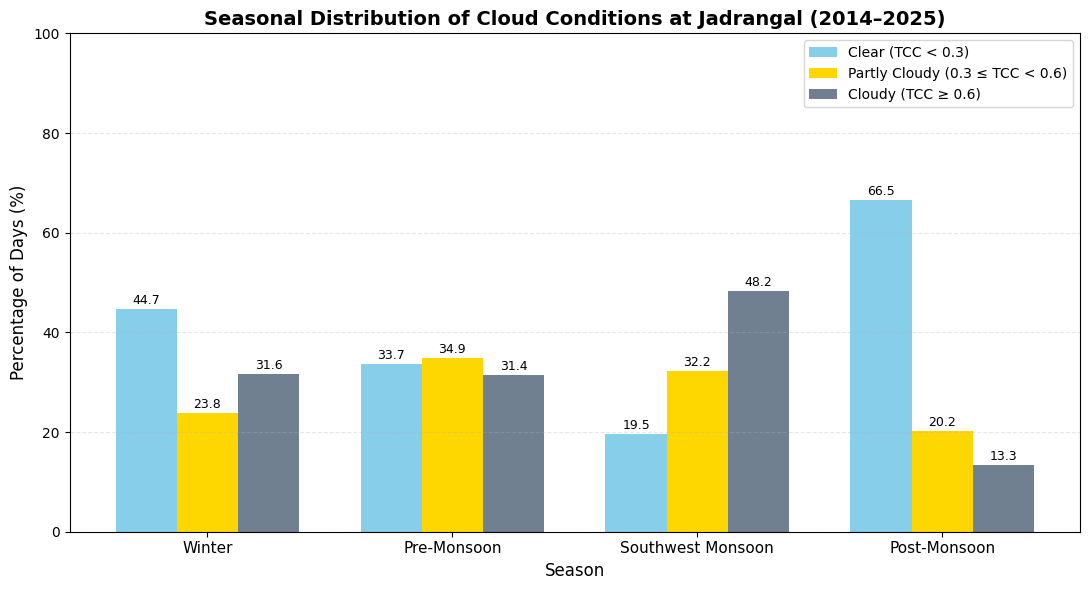

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Seasons
seasons = season_cloud_percent.index

# X positions
x = np.arange(len(seasons))

# Width of each bar
width = 0.25

plt.figure(figsize=(11, 6))

# Clear bars
plt.bar(
    x - width,
    season_cloud_percent["Clear"],
    width,
    label="Clear (TCC < 0.3)",
    color="skyblue"
)

# Partly cloudy bars
plt.bar(
    x,
    season_cloud_percent["Partly Cloudy"],
    width,
    label="Partly Cloudy (0.3 ≤ TCC < 0.6)",
    color="gold"
)

# Cloudy bars
plt.bar(
    x + width,
    season_cloud_percent["Cloudy"],
    width,
    label="Cloudy (TCC ≥ 0.6)",
    color="slategray"
)
# Add percentage values on bars
for i in range(len(seasons)):
    plt.text(
        x[i]-width,
        season_cloud_percent["Clear"][i] + 1,
        f'{season_cloud_percent["Clear"][i]:.1f}',
        ha='center',
        fontsize=9
    )

    plt.text(
        x[i],
        season_cloud_percent["Partly Cloudy"][i] + 1,
        f'{season_cloud_percent["Partly Cloudy"][i]:.1f}',
        ha='center',
        fontsize=9
    )

    plt.text(
        x[i]+width,
        season_cloud_percent["Cloudy"][i] + 1,
        f'{season_cloud_percent["Cloudy"][i]:.1f}',
        ha='center',
        fontsize=9
    )

plt.xticks(x, seasons, fontsize=11)

plt.ylabel("Percentage of Days (%)", fontsize=12)
plt.xlabel("Season", fontsize=12)

plt.title(
    "Seasonal Distribution of Cloud Conditions at Jadrangal (2014–2025)",
    fontsize=14,
    weight="bold"
)

plt.ylim(0, 100)

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.3
)

plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
overall_cloud = (
    daily_tcc["cloud_condition"]
    .value_counts(normalize=True)
    * 100
)

print(overall_cloud)

cloud_condition
Clear            38.972210
Cloudy           32.443758
Partly Cloudy    28.584032
Name: proportion, dtype: float64


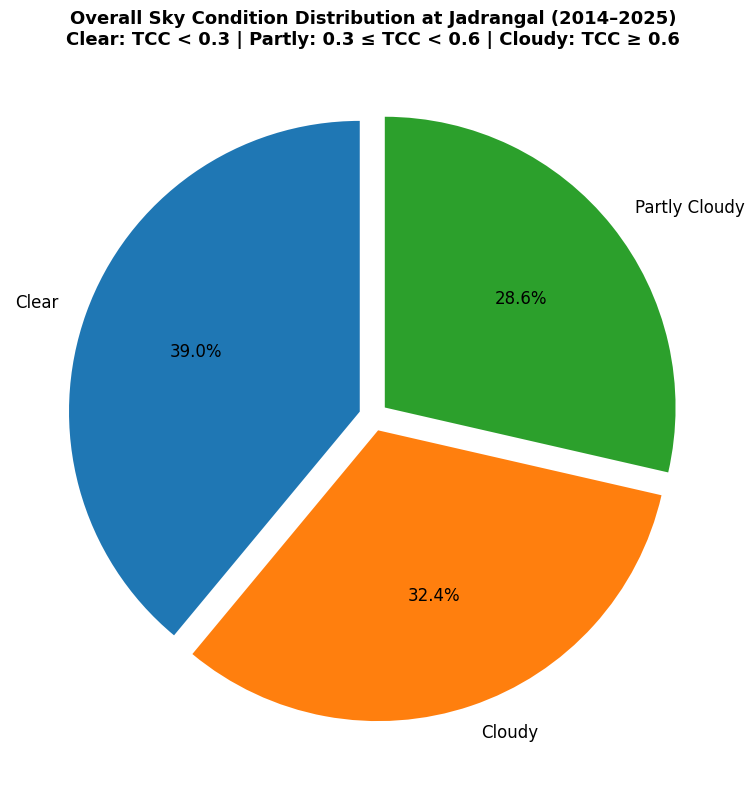

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 8))

plt.pie(
    overall_cloud.values,
    labels=overall_cloud.index,
    autopct="%1.1f%%",
    startangle=90,
    explode=[0.05, 0.05, 0.05],
    textprops={"fontsize": 12}
)

plt.title(
    "Overall Sky Condition Distribution at Jadrangal (2014–2025)\n"
    "Clear: TCC < 0.3 | Partly: 0.3 ≤ TCC < 0.6 | Cloudy: TCC ≥ 0.6",
    fontsize=13,
    weight="bold"
)

plt.tight_layout()
plt.show()

In [ ]:
annual_clear_percent = (
    daily_tcc.groupby("year")["cloud_condition"]
    .apply(lambda x: (x == "Clear").mean() * 100)
    .reset_index(name="clear_percentage")
)

print(annual_clear_percent)

    year  clear_percentage
0   2014         38.082192
1   2015         35.890411
2   2016         35.792350
3   2017         34.794521
4   2018         45.205479
5   2019         31.506849
6   2020         37.978142
7   2021         42.739726
8   2022         46.027397
9   2023         33.972603
10  2024         45.901639
11  2025         40.000000
12  2026         38.410596


In [ ]:
# Keep only 2014–2025
df_2014_2025 = daily_tcc[daily_tcc["year"] <= 2025]

# Create heatmap table
cloud_heatmap = (
    df_2014_2025
    .groupby(["year", "month"])["daily_tcc"]
    .mean()
    .unstack()
)

print(cloud_heatmap.head())

month        1         2         3         4         5         6         7   \
year                                                                          
2014   0.447741  0.490305  0.579450  0.462972  0.446278  0.335599  0.697950   
2015   0.361532  0.604128  0.610177  0.483947  0.415834  0.432269  0.855339   
2016   0.371319  0.228464  0.616213  0.532574  0.365154  0.459695  0.677270   
2017   0.565060  0.484183  0.509086  0.356662  0.515812  0.480751  0.783167   
2018   0.208286  0.466513  0.368949  0.398569  0.350976  0.454609  0.695711   

month        8         9         10        11        12  
year                                                     
2014   0.497865  0.406199  0.277568  0.188760  0.363474  
2015   0.666135  0.278667  0.274846  0.323468  0.303171  
2016   0.750364  0.370744  0.144216  0.288435  0.261332  
2017   0.645106  0.380185  0.144603  0.277295  0.362537  
2018   0.780788  0.516059  0.252802  0.357958  0.269768  


In [ ]:
annual_clear_days = (
    daily_tcc[
        (daily_tcc["cloud_condition"] == "Clear") &
        (daily_tcc["year"] <= 2025)
    ]
    .groupby("year")
    .size()
    .reset_index(name="clear_days")
)

print(annual_clear_days)

    year  clear_days
0   2014         139
1   2015         131
2   2016         131
3   2017         127
4   2018         165
5   2019         115
6   2020         139
7   2021         156
8   2022         168
9   2023         124
10  2024         168
11  2025         146


In [ ]:
mean_clear = annual_clear_days["clear_days"].mean()

std_clear = annual_clear_days["clear_days"].std()

print(f"Mean clear days = {mean_clear:.1f} ± {std_clear:.1f} days/year")

Mean clear days = 142.4 ± 18.2 days/year


In [ ]:
clear_fraction = mean_clear / 365 * 100
clear_fraction_std = std_clear / 365 * 100

print(f"Clear sky availability = {clear_fraction:.1f} ± {clear_fraction_std:.1f}%")

Clear sky availability = 39.0 ± 5.0%


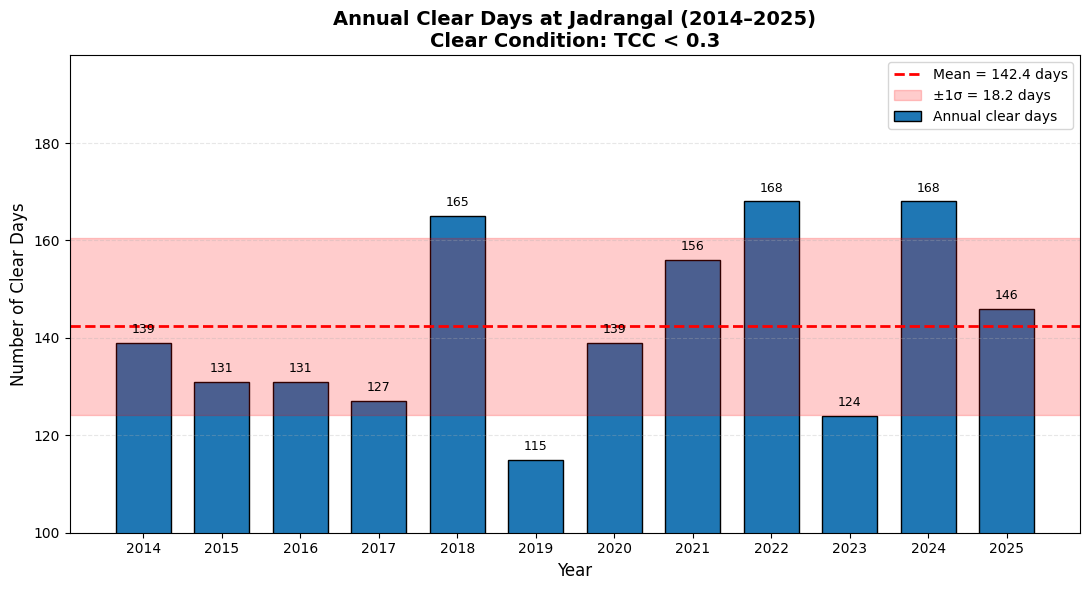

In [ ]:
import matplotlib.pyplot as plt

# Calculate mean and standard deviation
mean_days = annual_clear_days["clear_days"].mean()
std_days = annual_clear_days["clear_days"].std()

plt.figure(figsize=(11, 6))

# Bar plot
bars = plt.bar(
    annual_clear_days["year"],
    annual_clear_days["clear_days"],
    width=0.7,
    edgecolor="black",
    label="Annual clear days"
)

# Add values on bars
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 2,
        f"{int(height)}",
        ha="center",
        fontsize=9
    )

# Mean line
plt.axhline(
    mean_days,
    color="red",
    linestyle="--",
    linewidth=2,
    label=f"Mean = {mean_days:.1f} days"
)

# ±1 sigma region
plt.axhspan(
    mean_days - std_days,
    mean_days + std_days,
    color="red",
    alpha=0.2,
    label=f"±1σ = {std_days:.1f} days"
)

# Labels
plt.xlabel("Year", fontsize=12)
plt.ylabel("Number of Clear Days", fontsize=12)

plt.title(
    "Annual Clear Days at Jadrangal (2014–2025)\n"
    "Clear Condition: TCC < 0.3",
    fontsize=14,
    weight="bold"
)

# Axis settings
plt.xticks(annual_clear_days["year"])
plt.ylim(
    100,
    annual_clear_days["clear_days"].max() + 30
)

# Grid and legend
plt.grid(axis="y", linestyle="--", alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
annual_clear_days["clear_percent"] = (
    annual_clear_days["clear_days"] / 365 * 100
)

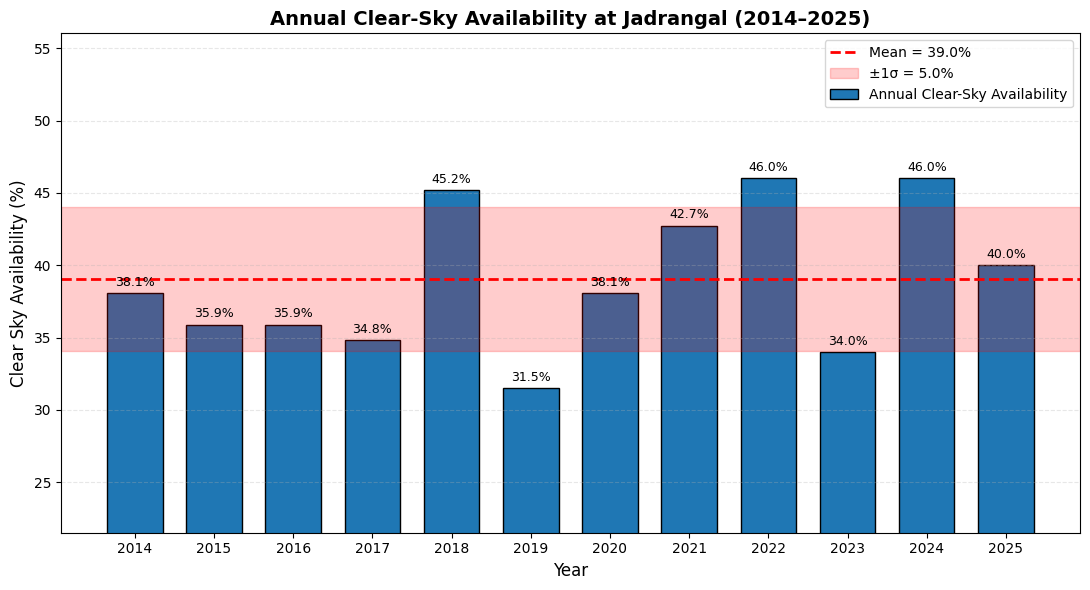

In [ ]:
import matplotlib.pyplot as plt

# Calculate mean and standard deviation
mean_percent = annual_clear_days["clear_percent"].mean()
std_percent = annual_clear_days["clear_percent"].std()

plt.figure(figsize=(11, 6))

# Bar plot
bars = plt.bar(
    annual_clear_days["year"],
    annual_clear_days["clear_percent"],
    width=0.7,
    edgecolor="black",
    label="Annual Clear-Sky Availability"
)

# Add percentage values on bars
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.5,
        f"{height:.1f}%",
        ha="center",
        fontsize=9
    )

# Mean line
plt.axhline(
    mean_percent,
    color="red",
    linestyle="--",
    linewidth=2,
    label=f"Mean = {mean_percent:.1f}%"
)

# ±1 sigma region
plt.axhspan(
    mean_percent - std_percent,
    mean_percent + std_percent,
    color="red",
    alpha=0.2,
    label=f"±1σ = {std_percent:.1f}%"
)

# Labels
plt.xlabel("Year", fontsize=12)
plt.ylabel("Clear Sky Availability (%)", fontsize=12)

plt.title(
    "Annual Clear-Sky Availability at Jadrangal (2014–2025)",
    fontsize=14,
    weight="bold"
)

# Axis settings
plt.xticks(annual_clear_days["year"])
plt.ylim(
    max(0, annual_clear_days["clear_percent"].min() - 10),
    annual_clear_days["clear_percent"].max() + 10
)

# Grid and legend
plt.grid(axis="y", linestyle="--", alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()